# Preprocessing of data for forecasting

### Setup   

In [10]:
# libraries
import matplotlib.pyplot as plt ## for basic plotting
import matplotlib as mpl ## for setting default parameters
import pandas as pd ## always
import os ## for handling file paths 1
from pathlib import Path ## for handling file paths 2
import numpy as np ## for numerical operations
import seaborn as sns ## for more advanced plotting
import scienceplots ## for better default plot styles
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [ ]:
# paths
base_dir = Path("/Users/hannahmaihojgaard/Documents/GitHub/datascience2026")
data_path = Path(base_dir / "forecasting_data")

# output path
output_csv = data_path / "daily_taxi_2013_2025.csv"

# list parquet files
files = sorted(data_path.glob("yellow_tripdata_*.parquet"))

print(f"Found: {len(files)} parquet files")

Found 156 parquet files


In [12]:
if output_csv.exists():
    output_csv.unlink()
    print("Old CSV removed")

print(f"Output will be saved to: {output_csv}")

Output will be saved to: /Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/daily_taxi_2013_2025.csv


In [ ]:
# function to clean each monthly taxi dataset
def clean_taxi_month(df):
    # Fill missing fee columns with 0 if they exist
    fee_columns = [
        "Airport_fee",
        "cbd_congestion_fee",
        "congestion_surcharge",
        "tolls_amount",
        "extra",
        "mta_tax"
    ]
    
    existing_fee_cols = [col for col in fee_columns if col in df.columns]

    df[existing_fee_cols] = df[existing_fee_cols].fillna(0)

    # Convert datetime columns
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

    df = df[
        (df["tpep_pickup_datetime"].dt.year >= 2013) &
        (df["tpep_pickup_datetime"].dt.year <= 2026)
    ].copy()

    # Calculate trip duration in minutes
    df["trip_duration"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    # Filter out unrealistic trips
    df = df[
        (df["trip_duration"] > 0) &
        (df["trip_duration"] <= 180) &
        (df["trip_distance"] > 0) &
        (df["trip_distance"] <= 100) &
        (df["fare_amount"] > 0) &
        (df["fare_amount"] <= 500)
    ].copy()

    # Filter out trips with more than 6 passengers 
    if "passenger_count" in df.columns:
        df = df[
            (df["passenger_count"].isna()) |
            (df["passenger_count"] <= 6)
        ].copy()

    return df

In [14]:
# function to aggregate daily metrics
def aggregate_daily(df):

    df = df.copy()

    df["date"] = df["tpep_pickup_datetime"].dt.date

    daily = df.groupby("date").agg(
        trip_count=("tpep_pickup_datetime", "count"),
        avg_fare=("fare_amount", "mean"),
        total_fare=("fare_amount", "sum"),
        avg_total_amount=("total_amount", "mean"),
        total_revenue=("total_amount", "sum"),
        avg_distance=("trip_distance", "mean"),
        avg_duration=("trip_duration", "mean"),
        avg_tip=("tip_amount", "mean"),
        avg_passengers=("passenger_count", "mean")
    ).reset_index()

    daily["date"] = pd.to_datetime(daily["date"])

    return daily

In [ ]:
# process each file and aggregate daily metrics
daily_dfs = []

for i, file in enumerate(files):

    print(f"\nProcessing {file.name}")

    df = pd.read_parquet(file)

    file_month = file.stem.replace("yellow_tripdata_", "")

    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

    df = df[
        df["tpep_pickup_datetime"].dt.to_period("M").astype(str) == file_month
    ].copy()

    clean_df = clean_taxi_month(df)

    daily_df = aggregate_daily(clean_df)

    daily_df["source_file"] = file_month

    daily_dfs.append(daily_df)

    if i == 0:
        daily_df.to_csv(output_csv, index=False, mode="w")
    else:
        daily_df.to_csv(output_csv, index=False, mode="a", header=False)

    print(f"Added {len(daily_df)} daily rows")


Processing yellow_tripdata_2013-01.parquet


/var/folders/zh/yn1dyvpd7qg1qt08qcp_qmgw0000gn/T/ipykernel_29659/1221606777.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[existing_fee_cols] = df[existing_fee_cols].fillna(0)


Added 31 daily rows

Processing yellow_tripdata_2013-02.parquet


/var/folders/zh/yn1dyvpd7qg1qt08qcp_qmgw0000gn/T/ipykernel_29659/1221606777.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[existing_fee_cols] = df[existing_fee_cols].fillna(0)


Added 28 daily rows

Processing yellow_tripdata_2013-03.parquet


...

Added 31 daily rows

Processing yellow_tripdata_2018-09.parquet
Added 30 daily rows

Processing yellow_tripdata_2018-10.parquet


/var/folders/zh/yn1dyvpd7qg1qt08qcp_qmgw0000gn/T/ipykernel_29659/1221606777.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[existing_fee_cols] = df[existing_fee_cols].fillna(0)


Added 31 daily rows

Processing yellow_tripdata_2018-11.parquet
Added 30 daily rows

Processing yellow_tripdata_2018-12.parquet


/var/folders/zh/yn1dyvpd7qg1qt08qcp_qmgw0000gn/T/ipykernel_29659/1221606777.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[existing_fee_cols] = df[existing_fee_cols].fillna(0)


Added 31 daily rows

Processing yellow_tripdata_2019-01.parquet
Added 31 daily rows

Processing yellow_tripdata_2019-02.parquet
Added 28 daily rows

Processing yellow_tripdata_2019-03.parquet
Added 31 daily rows

Processing yellow_tripdata_2019-04.parquet
Added 30 daily rows

Processing yellow_tripdata_2019-05.parquet
Added 31 daily rows

Processing yellow_tripdata_2019-06.parquet
Added 30 daily rows

Processing yellow_tripdata_2019-07.parquet
Added 31 daily rows

Processing yellow_tripdata_2019-08.parquet
Added 31 daily rows

Processing yellow_tripdata_2019-09.parquet
Added 30 daily rows

Processing yellow_tripdata_2019-10.parquet
Added 31 daily rows

Processing yellow_tripdata_2019-11.parquet
Added 30 daily rows

Processing yellow_tripdata_2019-12.parquet
Added 31 daily rows

Processing yellow_tripdata_2020-01.parquet
Added 31 daily rows

Processing yellow_tripdata_2020-02.parquet
Added 29 daily rows

Processing yellow_tripdata_2020-03.parquet
Added 31 daily rows

Processing yellow_t

In [ ]:
# concatenate all daily dataframes
daily_taxi = pd.concat(daily_dfs, ignore_index=True)

daily_taxi = (
    daily_taxi
    .sort_values("date")
    .reset_index(drop=True)
)

In [17]:
print("FINAL DATASET")
print(f"Rows: {daily_taxi.shape[0]}")
print(f"Columns: {daily_taxi.shape[1]}")
print(f"Duplicate dates: {daily_taxi['date'].duplicated().sum()}")

daily_taxi.head()

FINAL DATASET
Rows: 4748
Columns: 11
Duplicate dates: 0


,date,trip_count,avg_fare,total_fare,avg_total_amount,total_revenue,avg_distance,avg_duration,avg_tip,avg_passengers,source_file
0,2013-01-01,409050,12.725598,5205405.78,14.777094,6044570.15,3.375243,11.163758,1.068419,1.838066,2013-01
1,2013-01-02,389841,11.896467,4637730.76,14.138408,5511731.00,3.029305,11.230170,1.107561,1.715692,2013-01
2,2013-01-03,438155,11.465754,5023777.66,13.654552,5982810.04,2.789965,11.300080,1.116355,1.697518,2013-01
3,2013-01-04,475467,11.201410,5325900.58,13.375566,6359640.39,2.676159,11.121728,1.117325,1.708968,2013-01
4,2013-01-05,470595,11.224734,5282303.60,13.164564,6195177.81,2.765861,10.669944,1.074380,1.783281,2013-01


In [ ]:
# save final dataset
daily_taxi.to_csv(output_csv, index=False)

print(f"Final CSV saved to: {output_csv}")

Final CSV saved to: /Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/daily_taxi_2013_2025.csv


# Clean 2026 Q1 data

In [41]:
test_2026_files = sorted(
    data_path.glob("yellow_tripdata_2026-*.parquet")
)

test_2026_files

[PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2026-01.parquet'),
 PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2026-02.parquet'),
 PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2026-03.parquet')]

In [ ]:
test_2026_daily = []  # IIMPORTANTTTTTT: reset before rerunning

for file in test_2026_files:

    print(f"Processing {file.name}")

    df = pd.read_parquet(file)

    # Extract file month
    file_month = file.stem.replace("yellow_tripdata_", "")

    # Convert datetime before filtering
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

    # Keep only pickups from the month in the filename
    df = df[
        df["tpep_pickup_datetime"].dt.to_period("M").astype(str) == file_month
    ].copy()

    # Apply same cleaning steps as before
    df = clean_taxi_month(df)

    # Aggregate daily
    daily = aggregate_daily(df)

    test_2026_daily.append(daily)

Processing yellow_tripdata_2026-01.parquet
Processing yellow_tripdata_2026-02.parquet
Processing yellow_tripdata_2026-03.parquet


In [43]:
test_2026_df = pd.concat(test_2026_daily, ignore_index=True)

test_2026_df["date"] = pd.to_datetime(test_2026_df["date"])

test_2026_df = (
    test_2026_df
    .sort_values("date")
    .reset_index(drop=True)
)

In [44]:
test_2026_df.shape

(90, 10)

In [ ]:
#Quick sanity checks on 2026 data
print(test_2026_df["date"].min())
print(test_2026_df["date"].max())

2026-01-01 00:00:00
2026-03-31 00:00:00


In [ ]:
# check for duplicate dates
test_2026_df["date"].duplicated().sum()

0

In [ ]:
# check for missing dates in 2026
full_2026_range = pd.date_range(
    start="2026-01-01",
    end="2026-03-31",
    freq="D"
)

missing_2026 = full_2026_range.difference(
    test_2026_df["date"]
)

print(len(missing_2026))

missing_2026

0


DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [48]:
test_2026_df["date"].value_counts().sort_values(
    ascending=False
).head(20)

date
2026-01-01    1
2026-01-22    1
2026-01-04    1
2026-01-05    1
2026-01-06    1
2026-01-07    1
2026-01-08    1
2026-01-09    1
2026-01-10    1
2026-01-11    1
2026-01-12    1
2026-01-13    1
2026-01-14    1
2026-01-15    1
2026-01-16    1
2026-01-17    1
2026-01-18    1
2026-01-19    1
2026-01-20    1
2026-01-21    1
Name: count, dtype: int64

In [49]:
test_2026_df.to_csv(
    data_path / "daily_taxi_2026_q1.csv",
    index=False
)

# Creating Spatial Analysis Data

In [50]:
import geopandas as gpd

In [ ]:
#load taxi zone shapefile
shape_path = (
    data_path /
    "taxi_zones" /
    "taxi_zones.shp"
)

zones_gdf = gpd.read_file(shape_path)

zones_gdf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


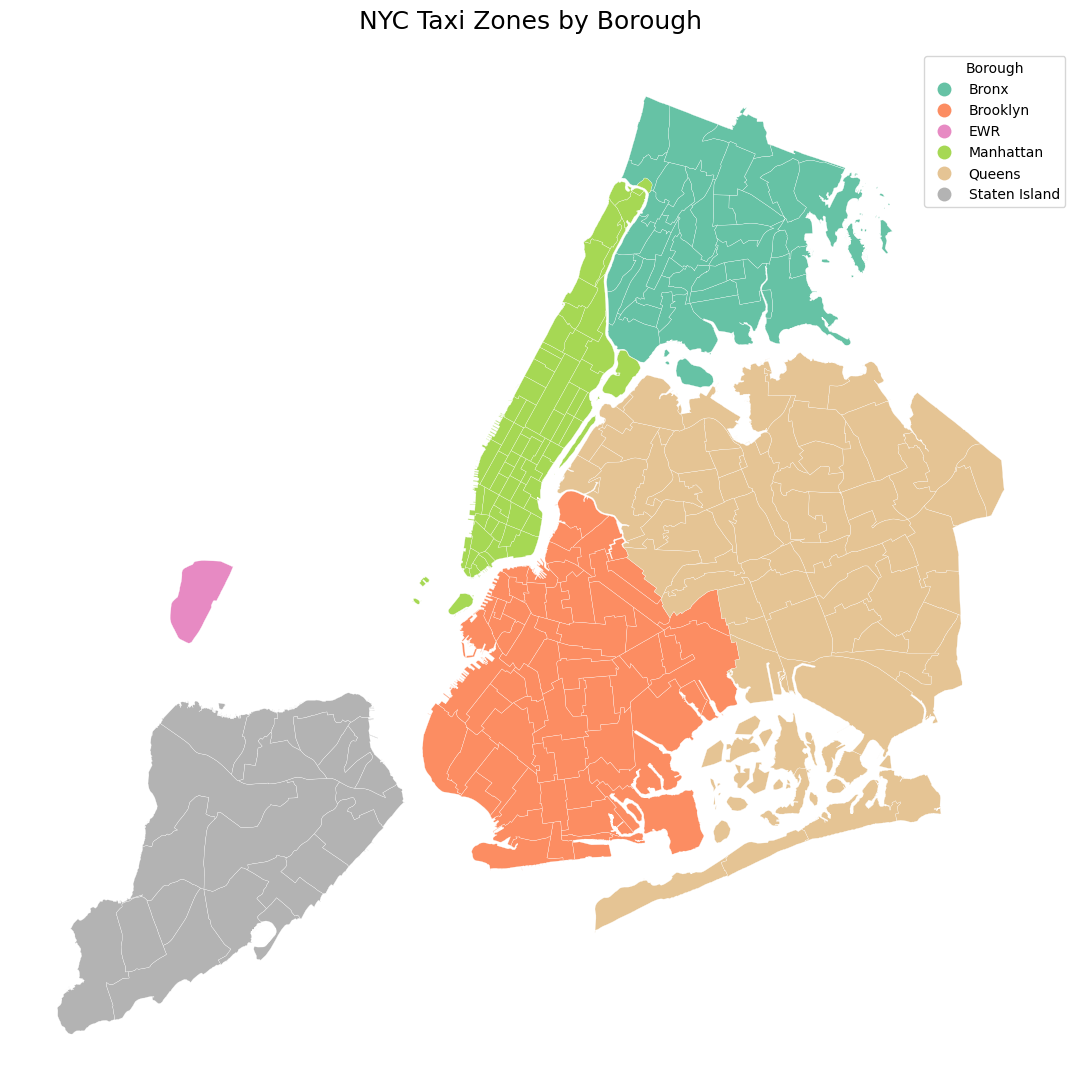

In [ ]:
#plotzzzz
fig, ax = plt.subplots(figsize=(11, 11))

zones_gdf.plot(
    ax=ax,
    column="borough",
    categorical=True,
    cmap="Set2",
    linewidth=0.2,
    edgecolor="white",
    legend=True
)

ax.set_title(
    "NYC Taxi Zones by Borough",
    fontsize=18,
    pad=15
)

ax.axis("off")

legend = ax.get_legend()

legend.set_bbox_to_anchor((1.02, 1))
legend.set_title("Borough")

plt.tight_layout()

plt.show()

### Build dataset

In [56]:
spatial_files = sorted(
    data_path.glob("yellow_tripdata_202[45]-*.parquet")
)

len(spatial_files), spatial_files[:3], spatial_files[-3:]

(24,
 [PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2024-01.parquet'),
  PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2024-02.parquet'),
  PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2024-03.parquet')],
 [PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2025-10.parquet'),
  PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2025-11.parquet'),
  PosixPath('/Users/hannahmaihojgaard/Documents/GitHub/datascience2026/forecasting_data/yellow_tripdata_2025-12.parquet')])

In [ ]:
# process each file and aggregate daily metrics by pickup zone
zone_daily_dfs = []

for file in spatial_files:
    
    print(f"Processing {file.name}")

    df = pd.read_parquet(file)

    file_month = file.stem.replace("yellow_tripdata_", "")

    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

    # Keep only trips from the file's actual month
    df = df[
        df["tpep_pickup_datetime"].dt.to_period("M").astype(str) == file_month
    ].copy()

    # Basic cleaning
    df = df[
        (df["trip_distance"] > 0) &
        (df["fare_amount"] > 0) &
        (df["PULocationID"].notna())
    ].copy()

    df["date"] = df["tpep_pickup_datetime"].dt.date
    df["date"] = pd.to_datetime(df["date"])

    daily_zone = (
        df
        .groupby(["date", "PULocationID"])
        .agg(
            trip_count=("tpep_pickup_datetime", "count"),
            avg_fare=("fare_amount", "mean"),
            avg_distance=("trip_distance", "mean")
        )
        .reset_index()
    )

    zone_daily_dfs.append(daily_zone)

zone_daily = pd.concat(zone_daily_dfs, ignore_index=True)

zone_daily.head()

Processing yellow_tripdata_2024-01.parquet
Processing yellow_tripdata_2024-02.parquet
Processing yellow_tripdata_2024-03.parquet
Processing yellow_tripdata_2024-04.parquet
Processing yellow_tripdata_2024-05.parquet
Processing yellow_tripdata_2024-06.parquet
Processing yellow_tripdata_2024-07.parquet
Processing yellow_tripdata_2024-08.parquet
Processing yellow_tripdata_2024-09.parquet
Processing yellow_tripdata_2024-10.parquet
Processing yellow_tripdata_2024-11.parquet
Processing yellow_tripdata_2024-12.parquet
Processing yellow_tripdata_2025-01.parquet
Processing yellow_tripdata_2025-02.parquet
Processing yellow_tripdata_2025-03.parquet
Processing yellow_tripdata_2025-04.parquet
Processing yellow_tripdata_2025-05.parquet
Processing yellow_tripdata_2025-06.parquet
Processing yellow_tripdata_2025-07.parquet
Processing yellow_tripdata_2025-08.parquet
Processing yellow_tripdata_2025-09.parquet
Processing yellow_tripdata_2025-10.parquet
Processing yellow_tripdata_2025-11.parquet
Processing 

,date,PULocationID,trip_count,avg_fare,avg_distance
0,2024-01-01,1,5,79.400000,3.426000
1,2024-01-01,3,1,35.270000,9.660000
2,2024-01-01,4,178,21.718596,3.668202
3,2024-01-01,7,143,27.381608,5.282657
4,2024-01-01,9,3,53.266667,14.126667


In [ ]:
# merge with zone lookup to get zone names and boroughs
zone_lookup = pd.read_csv(
    data_path / "taxi_zones" / "taxi_zone_lookup.csv"
)

zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:

zone_daily = zone_daily.merge(
    zone_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_daily.head()

,date,PULocationID,trip_count,avg_fare,avg_distance,LocationID,Borough,Zone,service_zone
0,2024-01-01,1,5,79.400000,3.426000,1,EWR,Newark Airport,EWR
1,2024-01-01,3,1,35.270000,9.660000,3,Bronx,Allerton/Pelham Gardens,Boro Zone
2,2024-01-01,4,178,21.718596,3.668202,4,Manhattan,Alphabet City,Yellow Zone
3,2024-01-01,7,143,27.381608,5.282657,7,Queens,Astoria,Boro Zone
4,2024-01-01,9,3,53.266667,14.126667,9,Queens,Auburndale,Boro Zone


In [ ]:

top_zones = (
    zone_daily
    .groupby(["PULocationID", "Zone", "Borough"])["trip_count"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

top_zones

,PULocationID,Zone,Borough,trip_count
0,237,Upper East Side South,Manhattan,3907641
1,161,Midtown Center,Manhattan,3835741
2,132,JFK Airport,Queens,3764632
3,236,Upper East Side North,Manhattan,3472497
4,162,Midtown East,Manhattan,2816098
5,186,Penn Station/Madison Sq West,Manhattan,2788106
6,230,Times Sq/Theatre District,Manhattan,2747268
7,142,Lincoln Square East,Manhattan,2588750
8,138,LaGuardia Airport,Queens,2501329
9,170,Murray Hill,Manhattan,2340821


In [ ]:
# create a complete date-zone panel to ensure no missing combinations
all_dates = pd.date_range(
    start=zone_daily["date"].min(),
    end=zone_daily["date"].max(),
    freq="D"
)

all_zones = zone_daily["PULocationID"].unique()

full_index = pd.MultiIndex.from_product(
    [all_dates, all_zones],
    names=["date", "PULocationID"]
)

zone_panel = (
    zone_daily
    .set_index(["date", "PULocationID"])
    .reindex(full_index)
    .reset_index()
)

zone_panel["trip_count"] = zone_panel["trip_count"].fillna(0)

In [65]:
zone_panel = zone_panel.merge(
    zone_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_panel.head()

,date,PULocationID,trip_count,avg_fare,avg_distance,LocationID_x,Borough_x,Zone_x,service_zone_x,LocationID_y,Borough_y,Zone_y,service_zone_y
0,2024-01-01,1,5.0,79.400000,3.426000,1.0,EWR,Newark Airport,EWR,1,EWR,Newark Airport,EWR
1,2024-01-01,3,1.0,35.270000,9.660000,3.0,Bronx,Allerton/Pelham Gardens,Boro Zone,3,Bronx,Allerton/Pelham Gardens,Boro Zone
2,2024-01-01,4,178.0,21.718596,3.668202,4.0,Manhattan,Alphabet City,Yellow Zone,4,Manhattan,Alphabet City,Yellow Zone
3,2024-01-01,7,143.0,27.381608,5.282657,7.0,Queens,Astoria,Boro Zone,7,Queens,Astoria,Boro Zone
4,2024-01-01,9,3.0,53.266667,14.126667,9.0,Queens,Auburndale,Boro Zone,9,Queens,Auburndale,Boro Zone


In [ ]:
zone_panel = zone_panel.sort_values(
    ["PULocationID", "date"]
).reset_index(drop=True)

zone_panel["lag_1"] = (
    zone_panel
    .groupby("PULocationID")["trip_count"]
    .shift(1)
)

zone_panel["lag_7"] = (
    zone_panel
    .groupby("PULocationID")["trip_count"]
    .shift(7)
)

zone_panel["rolling_mean_7"] = (
    zone_panel
    .groupby("PULocationID")["trip_count"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

zone_panel["day_of_week"] = zone_panel["date"].dt.dayofweek
zone_panel["month"] = zone_panel["date"].dt.month
zone_panel["is_weekend"] = (zone_panel["day_of_week"] >= 5).astype(int)

In [ ]:
# check how many rows have missing lag features
zone_panel_model = zone_panel.dropna(
    subset=["lag_1", "lag_7", "rolling_mean_7"]
).copy()

zone_panel_model.shape

(190412, 19)